In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl
%matplotlib inline
import warnings
warnings.simplefilter('ignore')

In [2]:
# Making Dataset (linear)
X, y = skl.datasets.make_classification(
    n_samples=1000, n_features=2, n_clusters_per_class=1, n_redundant=0
)

<Axes: xlabel='0', ylabel='1'>

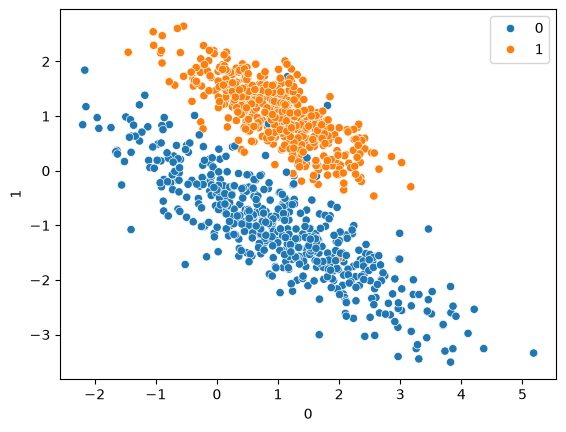

In [3]:
sns.scatterplot(x=pd.DataFrame(X)[0], y=pd.DataFrame(X)[1], hue=y)

In [4]:
# Train test split
X_train, X_test, y_train, y_test = skl.model_selection.train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [5]:
# Training by SVM
lin = skl.svm.SVC(kernel="linear")
lin.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [6]:
y_pred = lin.predict(X_test)

In [7]:
print(skl.metrics.confusion_matrix(y_test, y_pred))
print(skl.metrics.classification_report(y_test, y_pred))

[[128   1]
 [  0 121]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       129
           1       0.99      1.00      1.00       121

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250



In [8]:
# Making Dataset (overlapping)
X, y = skl.datasets.make_classification(
    n_samples=1000, n_features=2, n_clusters_per_class=2, n_redundant=0
)

<Axes: xlabel='0', ylabel='1'>

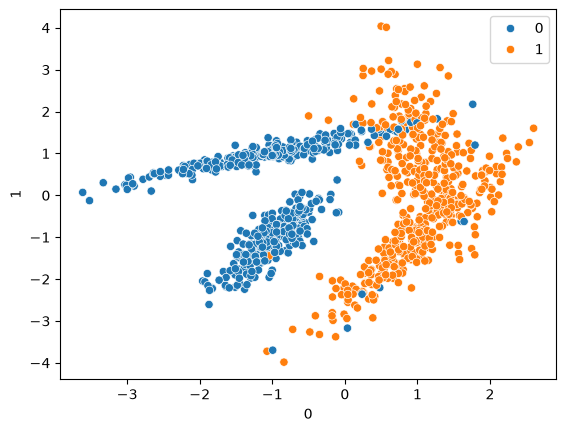

In [9]:
sns.scatterplot(x=pd.DataFrame(X)[0], y=pd.DataFrame(X)[1], hue=y)

### Using multiple kernels to check which one gives better accuracy


In [10]:
rbf = skl.svm.SVC(kernel="rbf")
rbf.fit(X_train, y_train)
y_pred = rbf.predict(X_test)
print(skl.metrics.confusion_matrix(y_test, y_pred))
print(skl.metrics.classification_report(y_test, y_pred))

[[128   1]
 [  0 121]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       129
           1       0.99      1.00      1.00       121

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250



In [11]:
sigmoid = skl.svm.SVC(kernel="sigmoid")
sigmoid.fit(X_train, y_train)
y_pred = sigmoid.predict(X_test)
print(skl.metrics.confusion_matrix(y_test, y_pred))
print(skl.metrics.classification_report(y_test, y_pred))

[[113  16]
 [ 22  99]]
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       129
           1       0.86      0.82      0.84       121

    accuracy                           0.85       250
   macro avg       0.85      0.85      0.85       250
weighted avg       0.85      0.85      0.85       250



In [12]:
poly = skl.svm.SVC(kernel="poly")
poly.fit(X_train, y_train)
y_pred = poly.predict(X_test)
print(skl.metrics.confusion_matrix(y_test, y_pred))
print(skl.metrics.classification_report(y_test, y_pred))

[[129   0]
 [  3 118]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       129
           1       1.00      0.98      0.99       121

    accuracy                           0.99       250
   macro avg       0.99      0.99      0.99       250
weighted avg       0.99      0.99      0.99       250



## Hyperparameter tuning


In [13]:
params_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "gamma": [0.1, 0.01, 0.001, 0.0001],
    "kernel": ["linear", "rbf", "sigmoid", "poly"],
}

In [14]:
# GridSearch CV
grid = skl.model_selection.GridSearchCV(
    estimator=skl.svm.SVC(), param_grid=params_grid, cv=5, n_jobs=-1
)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'gamma': [0.1, 0.01, ...], 'kernel': ['linear', 'rbf', ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information

In [15]:
grid.best_params_

{'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}

In [16]:
grid.best_score_

np.float64(0.9826666666666666)

In [17]:
y_pred = grid.predict(X_test)

In [18]:
print(skl.metrics.confusion_matrix(y_test, y_pred))
print(skl.metrics.classification_report(y_test, y_pred))

[[127   2]
 [  0 121]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       129
           1       0.98      1.00      0.99       121

    accuracy                           0.99       250
   macro avg       0.99      0.99      0.99       250
weighted avg       0.99      0.99      0.99       250



## SVM Kernel Implementation


In [19]:
x = np.linspace(-5.0, 5.0, 100)
y = np.sqrt(10**2 - x**2)
y = np.hstack([y, -y])
x = np.hstack([x, -x])

In [20]:
x1 = np.linspace(-5.0, 5.0, 100)
y1 = np.sqrt(5**2 - x1**2)
y1 = np.hstack([y1, -y1])
x1 = np.hstack([x1, -x1])

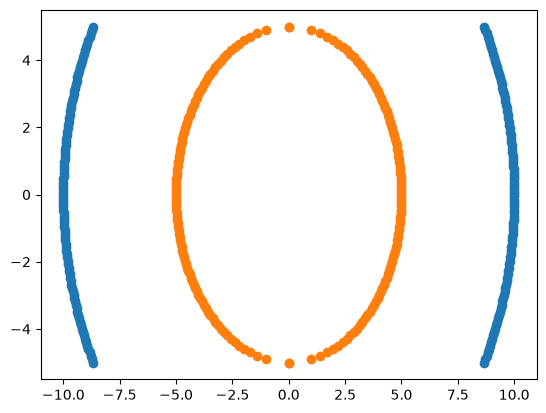

In [21]:
plt.scatter(y, x)
plt.scatter(y1, x1)

In [22]:
df1 = pd.DataFrame(np.vstack([y, x]).T, columns=["X1", "X2"])
df1["Y"] = 0
df2 = pd.DataFrame(np.vstack([y1, x1]).T, columns=["X1", "X2"])
df2["Y"] = 1
df = pd.concat([df1, df2], ignore_index=True)
df.head()

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


In [23]:
# Independent and Dependent features
X = df.iloc[:, :2]
y = df.Y

In [24]:
# Train test split
X_train, X_test, y_train, y_test = skl.model_selection.train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [26]:
df["X1 Square"] = df["X1"] ** 2
df["X2 Square"] = df["X2"] ** 2
df["X1 * X2"] = df["X1"] * df["X2"]

In [27]:
df.head()

,X1,X2,Y,X1 Square,X2 Square,X1 * X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [28]:
# Independent and Dependent features
X = df[["X1", "X2", "X1 Square", "X2 Square", "X1 * X2"]]
y = df["Y"]

In [29]:
X_train, X_test, y_train, y_test = skl.model_selection.train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [30]:
import plotly.express as px

fig = px.scatter_3d(df, x="X1", y="X2", z="X1 * X2", color="Y")
fig.show()

In [31]:
import plotly.express as px

fig = px.scatter_3d(df, x="X1 Square", y="X2 Square", z="X1 * X2", color="Y")
fig.show()

In [32]:
classifier = skl.svm.SVC(kernel="linear")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
score = skl.metrics.accuracy_score(y_test, y_pred)
print(score)

1.0


In [33]:
pol = skl.svm.SVC(kernel="poly")
pol.fit(X_train, y_train)
y_pred = pol.predict(X_test)
print(skl.metrics.accuracy_score(y_test, y_pred))

1.0


In [35]:
rbf = skl.svm.SVC(kernel="rbf")
rbf.fit(X_train, y_train)
y_pred = rbf.predict(X_test)
print(skl.metrics.accuracy_score(y_test, y_pred))

1.0


In [37]:
sigmoid = skl.svm.SVC(kernel="sigmoid")
sigmoid.fit(X_train, y_train)
y_pred = sigmoid.predict(X_test)
print(skl.metrics.accuracy_score(y_test, y_pred))

1.0
